A BASIC CHATBOT WITH LANGGRAPH

In [47]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [48]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]
graph_builder=StateGraph(State)

In [49]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [50]:
#LLM initialization

from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model ="llama-3.3-70b-versatile")

# OR llm=init_chat_model(model="llama3-8b-8192")
# llm

In [51]:
# Node functionality

def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

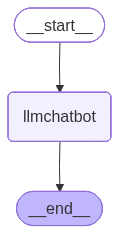

In [52]:
graph_builder=StateGraph(State)

# Adding node
graph_builder.add_node("llmchatbot", chatbot)

# Add edges to the graph
graph_builder.add_edge(START,"llmchatbot") # start to node llmchatbot
graph_builder.add_edge("llmchatbot",END) # Node llmchatbot to end

# Compile the graph
graph= graph_builder.compile()
graph

In [53]:
graph.invoke({"messages":"Hi"})

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='36a372a3-725e-479d-be1d-2aa659c3167a'),
  AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.049503715, 'completion_tokens_details': None, 'prompt_time': 0.001695695, 'prompt_tokens_details': None, 'queue_time': 0.050963045, 'total_time': 0.05119941}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019efa49-b146-7610-b379-c509df32c5a4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})]}

In [54]:
response=graph.invoke({"messages":"Hi"})
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [55]:
for event in graph.stream({"messages": "Hi, how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you might have. How about you? How's your day going?


CHATBOT WITH TOOL

In [56]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is LangGraph?")

{'query': 'What is LangGraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': '*   [Overview](https://www.ibm.com/think/topics/ai-agents#7281535). *   [What is agentic AI?](https://www.ibm.com/think/topics/agentic-ai#2095054954). *   [Overview](https://www.ibm.com/think/topics/ai-agent-development#1083937704). *   [Building AI agents](https://www.ibm.com/think/topics/how-to-build-an-ai-agent#1083937709). *   [Overview](https://www.ibm.com/think/topics/ai-agent-types#72820454). *   [Overview](https://www.ibm.com/think/topics/components-of-ai-agents#498277090). *   [Communication](https://www.ibm.com/think/topics/ai-agent-communication#498277088). *   [Learning](https://www.ibm.com/think/topics/ai-agent-learning#498277087). *   [Memory](https://www.ibm.com/think/topics/ai-agent-memory#498277086). *   [Perception](https://www.ibm.com/think/topics/ai-agen

In [57]:
# Custom function to just show how tool calling works. Without this as well LLm can do simple arithmetic operations

def multiply (a:int,b:int)->int:
    """Multiply a and b
    Args:
        a (int): first number
        b (int): second number
    Returns:
        int:output int
    """
    return a*b

In [58]:
tools=[tool,multiply]

In [59]:
llm_with_tools=llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000211721BF9D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000021172404410>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search 

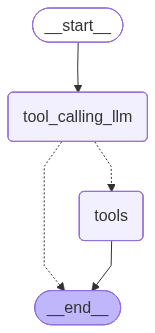

In [60]:
# State Graph with tools

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node definition for the tool node
def tool_calling_llm(state:State):  
    return{"messages":[llm_with_tools.invoke(state["messages"])]}

# Graph

builder=StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Add edges to the graph
builder.add_edge(START, "tool_calling_llm") #  start to node tool_calling_llm
builder.add_conditional_edges(
    "tool_calling_llm", 
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition      
)
builder.add_edge("tools", END) # Node tools to end

# Compile the graph
graph_with_tools= builder.compile()
graph_with_tools



In [61]:
response = graph_with_tools.invoke({"messages":"What is the recent AI news?"})

In [62]:
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.reuters.com/world/us/us-presses-meta-agree-ai-reviews-security-concerns-rise-nyt-reports-2026-06-23/", "title": "US presses Meta to agree to AI reviews as security concerns rise, NYT reports - Reuters", "score": 0.6211049, "published_date": "Tue, 23 Jun 2026 23:03:58 GMT", "content": "June 23 (Reuters) - The Trump administration is pressing Meta (META.O), opens new tab to submit its AI models for voluntary review, which would allow the government \u200bto evaluate their abilities and vulnerabilities, the New York Times \u200creported on Tuesday, citing four people familiar with the confidential request. Get weekly news and analysis on U.S. politics and how it matters to the world with the Reuters Politics U.S. newsletter. \\"We \u200bshare the administration\'s goal of advancing U.S. leadership on robust and secure frontier AI. Earlier this month, the U.S. government

In [63]:
for m in response["messages"]:
    print(m.pretty_print())

================================ Human Message =================================

What is the recent AI news?
None
================================== Ai Message ==================================
Tool Calls:
  tavily_search (276d1stzf)
 Call ID: 276d1stzf
  Args:
    query: recent AI news
    time_range: day
    topic: news
None
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.reuters.com/world/us/us-presses-meta-agree-ai-reviews-security-concerns-rise-nyt-reports-2026-06-23/", "title": "US presses Meta to agree to AI reviews as security concerns rise, NYT reports - Reuters", "score": 0.6211049, "published_date": "Tue, 23 Jun 2026 23:03:58 GMT", "content": "June 23 (Reuters) - The Trump administration is pressing Meta (META.O), opens new tab to submit its AI models for voluntary review, which would allow the governm

In [64]:
response_with_tools = graph_with_tools.invoke({"messages":"Give me recent AI news and then multiply 5 by 10."})
response_with_tools

{'messages': [HumanMessage(content='Give me recent AI news and then multiply 5 by 10.', additional_kwargs={}, response_metadata={}, id='dfb24f78-3cab-47e7-9d49-f11ca77cff22'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'zpgg55vfe', 'function': {'arguments': '{"query":"recent AI news","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': 'cfj3r5fsh', 'function': {'arguments': '{"a":5,"b":10}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 1803, 'total_tokens': 1845, 'completion_time': 0.112006093, 'completion_tokens_details': None, 'prompt_time': 0.198931235, 'prompt_tokens_details': None, 'queue_time': 0.052076791, 'total_time': 0.310937328}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019efa4b-8ee9-7271-b327-8a94160dc687-

In [65]:
for m in response_with_tools["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me recent AI news and then multiply 5 by 10.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (zpgg55vfe)
 Call ID: zpgg55vfe
  Args:
    query: recent AI news
    topic: news
  multiply (cfj3r5fsh)
 Call ID: cfj3r5fsh
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.economist.com/china/2026/06/21/china-is-having-another-ai-moment", "title": "China is having another AI moment - The Economist", "score": 0.64478505, "published_date": "Sun, 21 Jun 2026 16:50:29 GMT", "content": "# China is having another AI moment. ## A new model has narrowed the gap with America. America’s lead over China in artificial intelligence may be at its smallest in over a

ReAct Agent Architecture

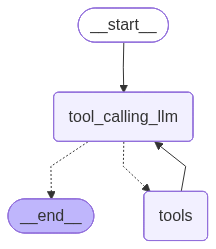

In [66]:
# State Graph with tools

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node definition for the tool node
def tool_calling_llm(state:State):  
    return{"messages":[llm_with_tools.invoke(state["messages"])]}

# Graph

builder=StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Add edges to the graph
builder.add_edge(START, "tool_calling_llm") #  start to node tool_calling_llm
builder.add_conditional_edges(
    "tool_calling_llm", 
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition      
)
builder.add_edge("tools", "tool_calling_llm") # Node tools back to tool_calling_llm

# Compile the graph
graph_with_tools= builder.compile()
graph_with_tools

In [67]:
response_with_tools = graph_with_tools.invoke({"messages":"Give me recent AI news and then multiply 5 by 10."})
response_with_tools

{'messages': [HumanMessage(content='Give me recent AI news and then multiply 5 by 10.', additional_kwargs={}, response_metadata={}, id='dd050940-451b-4641-9335-f2008369ec20'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'pwwh16mtp', 'function': {'arguments': '{"query":"recent AI news","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': '0ehn4f5z7', 'function': {'arguments': '{"a":5,"b":10}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 1803, 'total_tokens': 1845, 'completion_time': 0.12422023, 'completion_tokens_details': None, 'prompt_time': 0.210427881, 'prompt_tokens_details': None, 'queue_time': 0.052012624, 'total_time': 0.334648111}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019efa4b-93f3-73c2-a9a4-68795c8869d4-0

In [68]:
for m in response_with_tools["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me recent AI news and then multiply 5 by 10.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (pwwh16mtp)
 Call ID: pwwh16mtp
  Args:
    query: recent AI news
    topic: news
  multiply (0ehn4f5z7)
 Call ID: 0ehn4f5z7
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.economist.com/china/2026/06/21/china-is-having-another-ai-moment", "title": "China is having another AI moment - The Economist", "score": 0.64478505, "published_date": "Sun, 21 Jun 2026 16:50:29 GMT", "content": "# China is having another AI moment. ## A new model has narrowed the gap with America. America’s lead over China in artificial intelligence may be at its smallest in over a

In [69]:
# Above, LLM calls both tools - tavily search and multiply function. And then final answer correctly
# summarizes both the answers. 
# THE FLOW OF THE GRAPH IS EXACTLY THE ReAct agent approach i.e. reasoning -> action -> observation -> reasoning -> action -> observation ... and so on.

ADDING MEMORY IN AGENTIC GRAPH

In [70]:
response_with_tools = graph_with_tools.invoke({"messages":"Hello, my name is Alex."})
for m in response_with_tools["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello, my name is Alex.
================================== Ai Message ==================================

Hello Alex, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [71]:
response_with_tools = graph_with_tools.invoke({"messages":"What is my name?"})
for m in response_with_tools["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I don't have any information about your name. This conversation just started, and I don't have any prior knowledge about you. If you'd like to share your name, I'd be happy to chat with you!


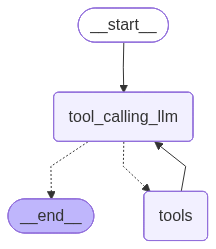

In [72]:
# State Graph with tools

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()

# Node definition for the tool node
def tool_calling_llm(state:State):  
    return{"messages":[llm_with_tools.invoke(state["messages"])]}

# Graph

builder=StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Add edges to the graph
builder.add_edge(START, "tool_calling_llm") #  start to node tool_calling_llm
builder.add_conditional_edges(
    "tool_calling_llm", 
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition      
)
builder.add_edge("tools", "tool_calling_llm") # Node tools back to tool_calling_llm

# Compile the graph
graph_with_tools= builder.compile(checkpointer=memory)
graph_with_tools

In [73]:
# Thread ID important for one specific session
config={"configurable": {"thread_id": "1"}}

response = graph_with_tools.invoke({"messages":"Hello, my name is Alex."},config=config)
response

{'messages': [HumanMessage(content='Hello, my name is Alex.', additional_kwargs={}, response_metadata={}, id='e124b1aa-9297-4e06-82a4-ca1ef9e072bf'),
  AIMessage(content="It's nice to meet you, Alex. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 1796, 'total_tokens': 1821, 'completion_time': 0.066931133, 'completion_tokens_details': None, 'prompt_time': 0.097948643, 'prompt_tokens_details': None, 'queue_time': 0.052816064, 'total_time': 0.164879776}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019efa4b-a069-7a51-acac-18cc18f8200f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1796, 'output_tokens': 25, 'total_tokens': 1821})]}

In [74]:
response = graph_with_tools.invoke({"messages":"Hello, what is my name?"},config=config)
response

{'messages': [HumanMessage(content='Hello, my name is Alex.', additional_kwargs={}, response_metadata={}, id='e124b1aa-9297-4e06-82a4-ca1ef9e072bf'),
  AIMessage(content="It's nice to meet you, Alex. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 1796, 'total_tokens': 1821, 'completion_time': 0.066931133, 'completion_tokens_details': None, 'prompt_time': 0.097948643, 'prompt_tokens_details': None, 'queue_time': 0.052816064, 'total_time': 0.164879776}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019efa4b-a069-7a51-acac-18cc18f8200f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1796, 'output_tokens': 25, 'total_tokens': 1821}),
  HumanMessage(content='Hello, what is my name?', additional_kwargs={},

In [75]:
print(response["messages"][-1].content)

Your name is Alex.


In [76]:
response = graph_with_tools.invoke({"messages":"Do you remember my name?"},config=config)
print(response["messages"][-1].content)

Yes, I remember your name. You're Alex.


STREAMING

In [77]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()


In [78]:
# Node definition
def superbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

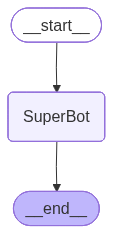

In [79]:
# Graph

graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)
graph_builder


In [80]:
# Invocation

configu ={"configurable": {"thread_id": "2"}}
graph_builder.invoke({"messages":"Hello, my name is Alex and I like cricket."},config=configu)

{'messages': [HumanMessage(content='Hello, my name is Alex and I like cricket.', additional_kwargs={}, response_metadata={}, id='f897df2e-d48c-4d5a-a5ac-c940873d0b13'),
  AIMessage(content="Hello Alex, it's nice to meet you. Cricket is a fantastic sport, with a rich history and a huge following worldwide. Are you a fan of a particular team or player? Do you have a favorite format of the game, such as Test matches, One-Day Internationals, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 46, 'total_tokens': 110, 'completion_time': 0.162994423, 'completion_tokens_details': None, 'prompt_time': 0.011686183, 'prompt_tokens_details': None, 'queue_time': 0.052859452, 'total_time': 0.174680606}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019efa4b-f6ed-7a03-9c04-42f557e5a306-0', tool_calls

Streaming
Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

values : This streams the full state of the graph after each node is called.

updates : This streams updates to the state of the graph after each node is called.

In [81]:
config = {"configurable": {"thread_id": "3"}}
for chunk in graph_builder.stream({"messages":"Hello, my name is Alex and I like ice cream?"},config, stream_mode="updates"):
    print(chunk)

# stream_mode = updates returns only the AI message


{'SuperBot': {'messages': [AIMessage(content="Hello Alex, it's nice to meet you. Ice cream is a great interest to have - there are so many delicious flavors to try. What's your favorite type of ice cream? Do you like classic flavors like vanilla or chocolate, or do you prefer something more unique like matcha or strawberry cheesecake?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 47, 'total_tokens': 110, 'completion_time': 0.185509308, 'completion_tokens_details': None, 'prompt_time': 0.008193019, 'prompt_tokens_details': None, 'queue_time': 0.052184359, 'total_time': 0.193702327}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019efa4b-f800-7532-a5c9-cd01e168619c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_tokens': 63, 'total_tokens': 110})]}}


In [ ]:
for chunk in graph_builder.stream({"messages":"Hello, my name is Alex and I like ice cream?"},config, stream_mode="values"):
    print(chunk)

# stream_mode = values returns the entire state of the graph at each step of the stream

{'messages': [HumanMessage(content='Hello, my name is Alex and I like ice cream?', additional_kwargs={}, response_metadata={}, id='019d6dc4-b29c-43bd-aeda-999eb218b0b6'), AIMessage(content="Hello Alex, it's nice to meet you. Ice cream is a great interest to have - there are so many delicious flavors to try. What's your favorite type of ice cream? Do you like classic flavors like vanilla or chocolate, or do you prefer something more unique like matcha or strawberry cheesecake?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 47, 'total_tokens': 110, 'completion_time': 0.185509308, 'completion_tokens_details': None, 'prompt_time': 0.008193019, 'prompt_tokens_details': None, 'queue_time': 0.052184359, 'total_time': 0.193702327}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019efa4b-f800-7532-a5

In [84]:
config = {"configurable": {"thread_id": "3"}}
for chunk in graph_builder.stream({"messages":"I also like all kinds of vegetarian food?"},config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hello, my name is Alex and I like ice cream?', additional_kwargs={}, response_metadata={}, id='019d6dc4-b29c-43bd-aeda-999eb218b0b6'), AIMessage(content="Hello Alex, it's nice to meet you. Ice cream is a great interest to have - there are so many delicious flavors to try. What's your favorite type of ice cream? Do you like classic flavors like vanilla or chocolate, or do you prefer something more unique like matcha or strawberry cheesecake?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 47, 'total_tokens': 110, 'completion_time': 0.185509308, 'completion_tokens_details': None, 'prompt_time': 0.008193019, 'prompt_tokens_details': None, 'queue_time': 0.052184359, 'total_time': 0.193702327}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019efa4b-f800-7532-a5

In [85]:
config = {"configurable": {"thread_id": "4"}}
async for event in graph_builder.astream_events({"messages":"I also like all kinds of vegetarian food?"},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'I also like all kinds of vegetarian food?'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019efa51-6cce-7170-bbe1-dc8eafae4daf', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='I also like all kinds of vegetarian food?', additional_kwargs={}, response_metadata={}, id='c5f5c027-daef-473d-806b-fec8b017f1a0'), AIMessage(content="Vegetarian food is amazing, with a wide variety of options to suit every taste and dietary preference. From hearty lentil soups to flavorful stir-fries, and from crispy veggie burgers to decadent eggplant parmesan, there's no shortage of delicious vegetarian dishes to try.\n\nWhat kind of vegetarian food do you enjoy the most? Are you a fan of Indian cuisine, with its rich and complex spice blends, or do you prefer the lighter, fresher flavors of Mediterranean or Middle Eastern food? Or perha